# Customer Churn Analysis and Model Development

This notebook documents the data cleaning, exploratory data analysis, model training,
evaluation, and model selection used for the Customer Churn Analysis Agent.

## Stage 1: Data Understanding and EDA

In [1]:
# Load the customer churn dataset and preview its size and first few rows
import pandas as pd

df = pd.read_csv("/content/Customer-Churn.csv")

print("Rows and columns:", df.shape)
df.head()

Rows and columns: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Inspect all column names and the data type Pandas assigned to each column
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [3]:
# Count how many unique values each column contains so we can understand which fields are categories vs. continuous values
print(df.nunique())

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64


In [4]:
# Show the actual categories used in the main text-based columns so we understand what each field represents
categorical_columns = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "Churn"
]

for column in categorical_columns:
    print(f"{column}: {df[column].unique()}")

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


In [5]:
# Check how many customers stayed vs. churned and what percentage each group represents
print("Churn counts:")
print(df["Churn"].value_counts())

print("\nChurn percentages:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentages:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [6]:
# Check each column for standard missing values before we begin cleaning the dataset
print("Missing values by column:")
print(df.isna().sum())

Missing values by column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [7]:
# Find TotalCharges values that cannot be converted into numbers so we can identify hidden data-quality issues
total_charges_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")

invalid_total_charges = df[total_charges_numeric.isna()]

print("Rows with non-numeric TotalCharges:", len(invalid_total_charges))
invalid_total_charges[["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

Rows with non-numeric TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [8]:
# Convert TotalCharges from text to numeric and set the 11 blank values for new customers to 0
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("TotalCharges data type:", df["TotalCharges"].dtype)
print("Missing TotalCharges values:", df["TotalCharges"].isna().sum())

TotalCharges data type: float64
Missing TotalCharges values: 0


In [9]:
# Check for duplicate rows and duplicate customer IDs so each customer is represented only once
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


In [10]:
# Review the main numeric columns to check their ranges, averages, and whether any values look unrealistic
numeric_columns = ["tenure", "MonthlyCharges", "TotalCharges"]

print(df[numeric_columns].describe())

            tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7043.000000
mean     32.371149       64.761692   2279.734304
std      24.559481       30.090047   2266.794470
min       0.000000       18.250000      0.000000
25%       9.000000       35.500000    398.550000
50%      29.000000       70.350000   1394.550000
75%      55.000000       89.850000   3786.600000
max      72.000000      118.750000   8684.800000


In [11]:
# Compare churn percentages across contract types to see whether contract length may be related to customers leaving
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn.round(2))

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


In [12]:
# Compare average tenure and charges for customers who stayed vs. customers who churned
churn_numeric_summary = df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean()

print(churn_numeric_summary.round(2))

       tenure  MonthlyCharges  TotalCharges
Churn                                      
No      37.57           61.27       2549.91
Yes     17.98           74.44       1531.80


In [13]:
# Compare churn percentages across internet service types to see whether service type is related to churn
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(internet_churn.round(2))

Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


In [14]:
# Compare churn rates across all categorical customer features so we can systematically look for useful patterns
eda_categorical_columns = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

for column in eda_categorical_columns:
    churn_rates = pd.crosstab(
        df[column],
        df["Churn"],
        normalize="index"
    ) * 100

    print(f"\n{column}")
    print(churn_rates.round(2))


gender
Churn      No    Yes
gender              
Female  73.08  26.92
Male    73.84  26.16

SeniorCitizen
Churn             No    Yes
SeniorCitizen              
0              76.39  23.61
1              58.32  41.68

Partner
Churn       No    Yes
Partner              
No       67.04  32.96
Yes      80.34  19.66

Dependents
Churn          No    Yes
Dependents              
No          68.72  31.28
Yes         84.55  15.45

PhoneService
Churn            No    Yes
PhoneService              
No            75.07  24.93
Yes           73.29  26.71

MultipleLines
Churn                No    Yes
MultipleLines                 
No                74.96  25.04
No phone service  75.07  24.93
Yes               71.39  28.61

InternetService
Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40

OnlineSecurity
Churn                   No    Yes
OnlineSecurity                   
No                   58.23  4

In [15]:
# Group customers into tenure ranges and compare churn rates to see how customer longevity relates to churn
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"]
)

tenure_churn = pd.crosstab(
    df["tenure_group"],
    df["Churn"],
    normalize="index"
) * 100

print(tenure_churn.round(2))

Churn            No    Yes
tenure_group              
0-12 months   52.56  47.44
13-24 months  71.29  28.71
25-48 months  79.61  20.39
49-72 months  90.49   9.51


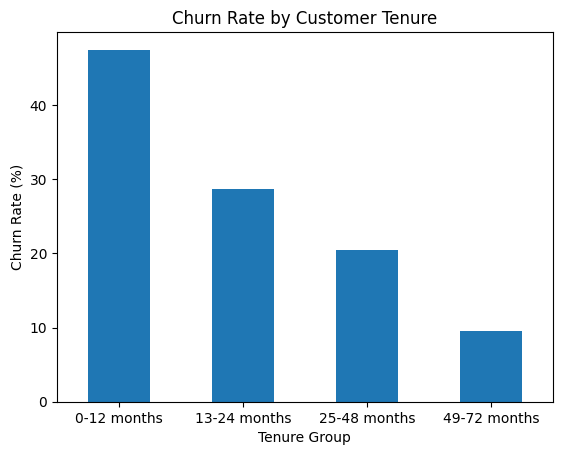

In [16]:
# Visualize churn rate across tenure groups so the relationship is easier to see
import matplotlib.pyplot as plt

tenure_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [17]:
# Group customers by monthly charge range and compare churn rates to see whether higher monthly costs are related to churn
df["monthly_charge_group"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 40, 70, 90, 120],
    labels=["$0-$40", "$40-$70", "$70-$90", "$90-$120"]
)

monthly_charge_churn = pd.crosstab(
    df["monthly_charge_group"],
    df["Churn"],
    normalize="index"
) * 100

print(monthly_charge_churn.round(2))

Churn                    No    Yes
monthly_charge_group              
$0-$40                88.36  11.64
$40-$70               76.08  23.92
$70-$90               62.20  37.80
$90-$120              67.22  32.78


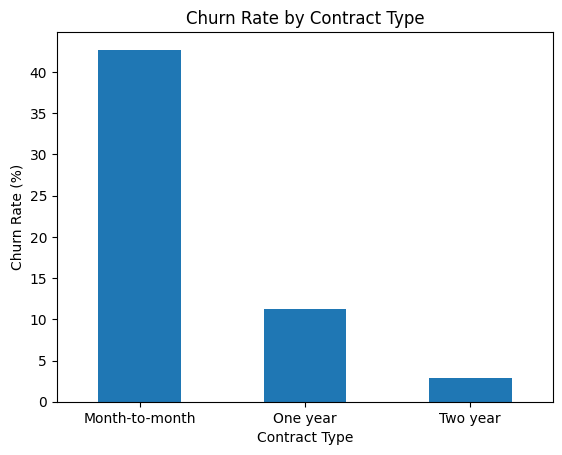

In [18]:
# Visualize churn rate by contract type because contract length showed one of the strongest relationships with churn
contract_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

## Stage 1 Summary

*   The dataset contains 7,043 unique customers and 21 original columns.
*   About 26.5% of customers churned, while 73.5% stayed, so the target is somewhat imbalanced.
*   *TotalCharges* was originally stored as text because 11 new customers with tenure = 0 had blank values. I converted the column to numeric and treated those accumulated charges as 0.
*   No duplicate rows or duplicate customer IDs were found.
*   Month-to-month customers had a much higher churn rate (42.7%) than one-year (11.3%) and two-year customers (2.8%).
*   Churn decreased strongly as customer tenure increased. Customers in their first year had a 47.4% churn rate, compared with 9.5% for customers with 49-72 months of tenure.
*   Customers who churned had shorter average tenure and higher average monthly charges.
*   Fiber optic customers, senior citizens, customers using electronic checks, and customers without services such as online security or tech support also showed higher churn rates.
*   Gender and phone service showed relatively little difference in churn.
*   These are associations found in the dataset and do not necessarily mean that any individual feature causes churn.

## Stage 2: Churn Prediction Model Training and Evaluation

In [19]:
# Prepare the modeling data by separating customer features from the churn outcome we want to predict

# Remove columns that should not be used as model inputs
X = df.drop(
    columns=[
        "customerID",
        "Churn",
        "tenure_group",
        "monthly_charge_group"
    ]
).copy()

# Convert the target from Yes/No into 1/0
y = df["Churn"].map({"No": 0, "Yes": 1})

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)

print("\nModel features:")
print(X.columns.tolist())

print("\nTarget values:")
print(y.value_counts())

Feature data shape: (7043, 19)
Target data shape: (7043,)

Model features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

Target values:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [20]:
# Split the dataset into training and testing groups while preserving the churn class balance
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training customers:", X_train.shape[0])
print("Testing customers:", X_test.shape[0])

print("\nTraining churn percentage:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting churn percentage:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training customers: 5634
Testing customers: 1409

Training churn percentage:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64

Testing churn percentage:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


In [21]:
# Separate numeric and categorical features so we can preprocess each type appropriately

numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    column for column in X.columns
    if column not in numeric_features
]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Numeric features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Number of numeric features: 4
Number of categorical features: 15


In [22]:
# Build preprocessing rules: scale numeric features and one-hot encode categorical features
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [23]:
# Combine preprocessing and Logistic Regression into one pipeline, then train it on the training customers
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [24]:
# Use the trained model to predict churn outcomes and churn probabilities for the unseen test customers

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Number of test predictions:", len(y_pred))
print("First 10 predicted churn outcomes:", y_pred[:10])
print("First 10 churn probabilities:", y_prob[:10].round(3))

Number of test predictions: 1409
First 10 predicted churn outcomes: [0 1 0 0 0 1 0 0 0 0]
First 10 churn probabilities: [0.046 0.684 0.059 0.402 0.021 0.603 0.448 0.13  0.003 0.395]


In [25]:
# Compare actual churn outcomes with model predictions to see where the model is correct and where it makes mistakes
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:")
print(cm)

Confusion matrix:
[[926 109]
 [165 209]]


The confusion matrix shows that the model correctly identified 926 customers who stayed and 209 customers who churned. It missed 165 actual churners and incorrectly flagged 109 customers as churn risks. The missed churners help explain why recall is important for this retention use case.

In [26]:
# Calculate several evaluation metrics so we can judge the model beyond accuracy alone
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1 Score:", round(f1, 3))
print("ROC-AUC:", round(roc_auc, 3))

Accuracy: 0.806
Precision: 0.657
Recall: 0.559
F1 Score: 0.604
ROC-AUC: 0.842


In [27]:
# Compare the trained model against a simple baseline that predicts every customer will stay

baseline_accuracy = (y_test == 0).mean()

print("Baseline accuracy (predict everyone stays):", round(baseline_accuracy, 3))
print("Logistic Regression accuracy:", round(accuracy, 3))
print("Logistic Regression ROC-AUC:", round(roc_auc, 3))

Baseline accuracy (predict everyone stays): 0.735
Logistic Regression accuracy: 0.806
Logistic Regression ROC-AUC: 0.842


In [28]:
# Train a Random Forest as a second model so we can compare it with our simpler Logistic Regression baseline
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest Accuracy:", round(rf_accuracy, 3))
print("Random Forest Recall:", round(rf_recall, 3))
print("Random Forest F1 Score:", round(rf_f1, 3))
print("Random Forest ROC-AUC:", round(rf_roc_auc, 3))

Random Forest Accuracy: 0.784
Random Forest Recall: 0.481
Random Forest F1 Score: 0.541
Random Forest ROC-AUC: 0.821


## Model Comparison and Selection

I started with Logistic Regression as a simple and interpretable baseline that also provides churn probabilities. I compared it with a Random Forest to test whether a more flexible nonlinear model would improve performance.

Logistic Regression performed better across the main evaluation metrics, including accuracy (80.6% vs. 78.4%), recall (55.9% vs. 48.1%), F1 score (0.604 vs. 0.541), and ROC-AUC (0.842 vs. 0.821). Based on these results, I selected Logistic Regression as the final churn model.

I chose ROC-AUC as the main overall metric because the application will use churn probabilities and risk ranking, while also monitoring recall because missing customers who actually churn is important in a retention use case.

In [2]:
# Wrap the trained model in a reusable function so other parts of the app can request a churn prediction

def predict_churn(customer_data):
    customer_df = pd.DataFrame([customer_data])

    churn_probability = model.predict_proba(customer_df)[0, 1]
    churn_prediction = model.predict(customer_df)[0]
    probability = float(churn_probability)

    return {
        "prediction": "Churn" if churn_prediction == 1 else "Stay",
        "churn_probability": round(probability, 4),
        "churn_probability_percent": round(probability * 100, 2)
    }

print("Prediction function created successfully.")

Prediction function created successfully.


In [30]:
# Test the reusable prediction function on one real customer from the unseen test set

sample_customer = X_test.iloc[0].to_dict()
sample_result = predict_churn(sample_customer)

print("Sample customer prediction:")
print(sample_result)

print("\nActual churn outcome:")
print("Churn" if y_test.iloc[0] == 1 else "Stay")

Sample customer prediction:
{'prediction': 'Stay', 'churn_probability': 0.0459}

Actual churn outcome:
Stay


## Stage 2 Summary

I prepared 19 customer features and split the dataset into **80% training data and 20% testing data**, while preserving the original churn distribution. The training set is what the model learns from, while the test set contains customers the model did not see during training and is used to measure how well it generalizes to new data.

Before training, numeric features were scaled so that features with much larger values, such as *TotalCharges*, would not dominate simply because of their size. Categorical text features, such as *Contract* and *InternetService*, were converted into model-readable numeric columns using one-hot encoding. These steps were combined into a preprocessing pipeline so that the exact same transformations are automatically used during both training and future predictions.

I trained **Logistic Regression** as the initial churn model because it is relatively simple, produces churn probabilities, and is easy to explain. I also compared it with a **Random Forest**, which is a more flexible model capable of learning more complex relationships between customer features. Logistic Regression performed better across the main metrics, so I selected it as the final model.

The Logistic Regression results were:

*   Accuracy: 80.6%
    
    This means the model predicted the correct stay/churn outcome for about 81% of all test customers. Accuracy alone is not enough here because about 73.5% of customers stayed, meaning a useless model that predicted “Stay” for everyone would already achieve about 73.5% accuracy.
*   Precision: 65.7%
    
    Of the customers the model predicted would churn, about 66% actually churned. Higher precision means fewer false churn warnings.
*   Recall: 55.9%

    Of all customers who actually churned, the model successfully identified about 56% of them. Recall is especially important for churn because a false negative represents a customer who was actually at risk but was missed by the model.
*   F1 Score: 0.604

    F1 combines precision and recall into one score. It is useful when both catching churners and limiting false alarms matter.
*   ROC-AUC: 0.842

    This measures how well the model generally ranks customers who churn above customers who stay across different classification thresholds. A score of 0.842 suggests the model does a good job separating higher-risk from lower-risk customers.

I chose ROC-AUC as the main overall metric because the final application will use churn probabilities and risk rankings rather than relying only on a Yes/No prediction. I also kept recall in mind because missing customers who actually churn could be costly in a real retention use case.

Finally, I wrapped the trained preprocessing and Logistic Regression pipeline in a reusable predict_churn() function. The function accepts one customer’s information and returns both a readable Stay/Churn prediction and the model’s calculated churn probability. This will later allow the agent to use the model as a tool without needing to know the underlying preprocessing or modeling details.

## Stage 3: Data Analysis Tools and Project Setup

In [31]:
# Save the final trained model and cleaned dataset so they can be reused by the application later
import joblib

# Save the trained preprocessing + Logistic Regression pipeline
joblib.dump(model, "/content/churn_model.joblib")

# Remove the temporary EDA grouping columns before saving the cleaned application dataset
clean_df = df.drop(
    columns=["tenure_group", "monthly_charge_group"]
).copy()

clean_df.to_csv("/content/customer_churn_clean.csv", index=False)

print("Saved model: churn_model.joblib")
print("Saved cleaned data: customer_churn_clean.csv")
print("Cleaned data shape:", clean_df.shape)

Saved model: churn_model.joblib
Saved cleaned data: customer_churn_clean.csv
Cleaned data shape: (7043, 21)


In [32]:
# Record the Python and library versions used to train the saved model
import sys
import pandas as pd
import sklearn
import joblib

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("joblib:", joblib.__version__)

Python: 3.12.13
pandas: 2.2.3
scikit-learn: 1.6.1
joblib: 1.5.3


## Stage 3 Summary

I moved the cleaned dataset and trained model from Colab into a structured local Python project and created a Python 3.12 virtual environment with matching model dependencies.

I separated the application logic into reusable data and model tools. The data tools calculate dataset summaries, category counts, category-level churn rates, numeric statistics, and customer lookups directly from the cleaned CSV. The model tools load the saved Logistic Regression pipeline, predict churn risk for individual customers, and rank customers by predicted churn probability.

I tested the saved model locally and confirmed that it could make predictions without retraining. I also tested a multi-tool workflow where a customer is first retrieved by ID and then passed into the churn prediction tool. This establishes the reliable computation layer that the AI agent can use in the next stage instead of generating statistics or predictions itself.

The exported model and cleaned CSV were then placed in the repository's models/ and data/ directories for use by the local application.

## Stage 4: Agent and LLM Integration

## Stage 4 Summary — Agent and LLM Integration

I connected the application to Groq using *openai/gpt-oss-20b* and built an agent layer around the existing data and churn-model functions.

The agent uses a controlled tool registry so the LLM can only request explicitly approved Python functions. I also created agent-facing wrapper functions for operations where the underlying Python interface was too complex for an LLM. For example, the original churn prediction function expects 19 customer features, while *predict_customer_churn(customer_id)* allows the agent to provide only an ID and lets trusted Python code retrieve and prepare the required features. Similarly, the high-risk customer wrapper keeps the dataframe internal instead of asking the LLM to provide one.

I initially tested Groq's native tool calling, but compound questions sometimes resulted in only the first required tool being selected. I changed the planning layer to strict structured JSON output so the LLM explicitly returns a list of every computation needed. This successfully handled multi-part questions while keeping the normal workflow to approximately two LLM calls: one for planning and one for the final explanation.

The full workflow is:

```
User question
    ↓
LLM creates structured plan
    ↓
Python validates requested tools
    ↓
Approved tools perform real calculations
    ↓
Results are verified
    ↓
One controlled retry if verification fails
    ↓
LLM explains only verified computed results
```

Testing confirmed that the agent can answer dataset questions, run model predictions, combine multiple computations in one answer, and refuse to provide unsupported results when a tool fails.

I also added a controlled what-if prediction tool for existing customers. Python retrieves the customer's real data, validates an approved feature change, applies it temporarily, and recomputes churn risk without modifying the source dataset. Numerical percentages are calculated in Python so the LLM only explains verified values rather than performing its own arithmetic.

## Application Integration

The trained model and cleaned dataset from this notebook were integrated into a
Streamlit-based LLM analysis agent. The final application includes structured tool
planning, verified Python computations, what-if churn predictions, and Dockerized
deployment. The implementation is available in the repository source files.